In [37]:
import os
os.chdir('/home/domingos/Dropbox/py scripts')
print(os.getcwd())
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.pylab import rcParams
from pmdarima.arima import KPSSTest
rcParams['figure.figsize'] = 15, 6

import locale
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
import matplotlib as mpl
mpl.rcParams['axes.formatter.use_locale'] = True

%load_ext autoreload
%autoreload 2

/home/domingos/Dropbox/py scripts
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from statsmodels.tsa.stattools import acf, pacf

def get_acf(ts, test_size, i_d):
    rcParams['figure.figsize'] = 15, 4

    lag_acf = acf(ts[0:-test_size], nlags=20)
    if i_d['name']== 'star':
        lag_pacf = pacf(ts, nlags=20)
    else:
        lag_pacf = pacf(ts[0:-test_size], nlags=20)
    #Plot ACF: 

    N = len(lag_acf)
    values = lag_acf
    ind = np.arange(N)    # the x locations for the groups
    width = 0.35       # the width of the bars: can also be len(x) sequence
    plt.subplot(122)
    p1 = plt.bar(ind, values, width,color='#000000')
    plt.axhline(y=0,linestyle='--',color='gray')
    plt.axhline(y=-1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
    plt.axhline(y=1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
    ax = plt.title('Função de Autocorrelação')

    N = len(lag_pacf)
    values = lag_pacf
    ind = np.arange(N)    # the x locations for the groups
    width = 0.35       # the width of the bars: can also be len(x) sequence
    plt.subplot(121)
    p1 = plt.bar(ind, values, width,color='#000000')
    plt.axhline(y=0,linestyle='--',color='gray')
    plt.axhline(y=-1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
    plt.axhline(y=1.96/np.sqrt(len(ts)),linestyle='--',color='gray')
    ax = plt.title('Função de Autocorrelação Parcial')
    fig = ax.get_figure()
    plt.savefig(f"{i_d['name']}_acf.pdf", bbox_inches='tight')
    plt.show()
    
    df=pd.DataFrame({'x': list(range(1,len(ts)+1)), 'Actual':ts})
                
    plt.plot('x', 'Actual', data=df,  color='black', linewidth=2,linestyle='-')
                
    plt.ylabel(i_d['label_y'])
    plt.xlabel(i_d['label_x'])
    plt.margins(0.01,0.01)
    ticks = list(range(1, len(ts)+1, int(len(ts)/10) ))
    plt.xticks(ticks)
    size=20
    params = {'legend.fontsize': 'xx-large',
              'figure.figsize': (10,3),
              'axes.labelsize': size,
              'axes.titlesize': size,
              'xtick.labelsize': size*0.75,
              'ytick.labelsize': size*0.75,
              'axes.titlepad': 50}
    
    plt.rcParams.update(params)
    plt.legend('',frameon=False)
    plt.savefig(f"{i_d['name']}_ts.pdf", bbox_inches='tight')
    plt.show()
    limit = 1.96/np.sqrt(len(ts))
    test_list = [ True if p>limit or p<-limit else False for p in lag_pacf]
    print([i for i, val in enumerate(test_list) if val])

In [48]:
with open('./zhang_bagg/models_configuration_60_20_20.json') as f:
    data = json.load(f)

lynx
(0.1, False)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


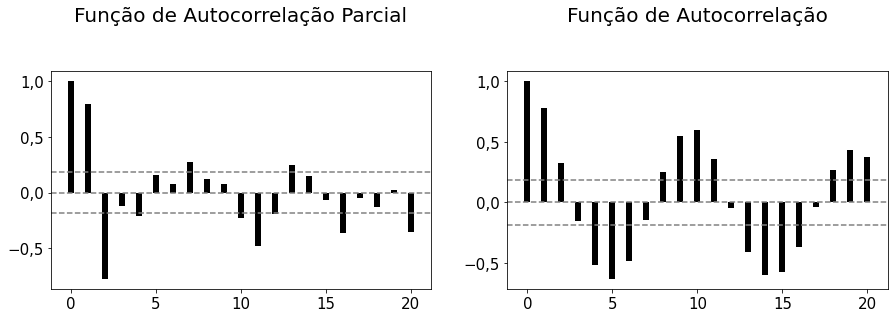

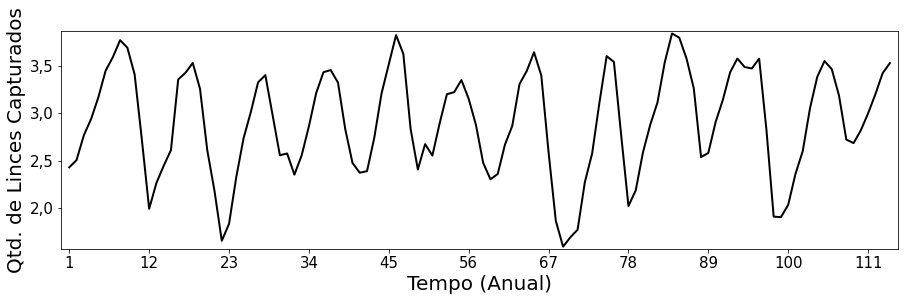

[0, 1, 2, 4, 7, 10, 11, 12, 13, 16, 20]
sunspot
(0.1, False)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


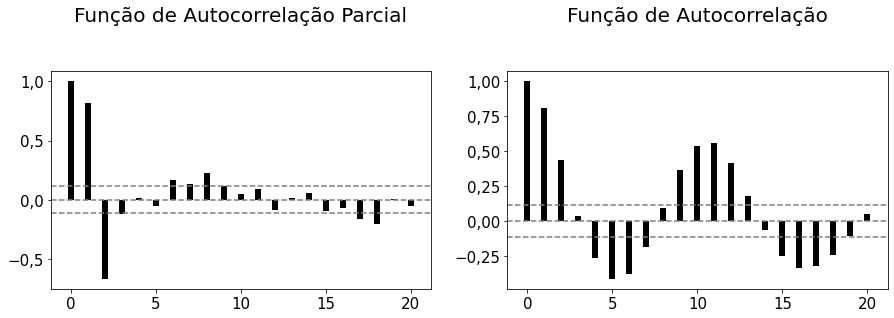

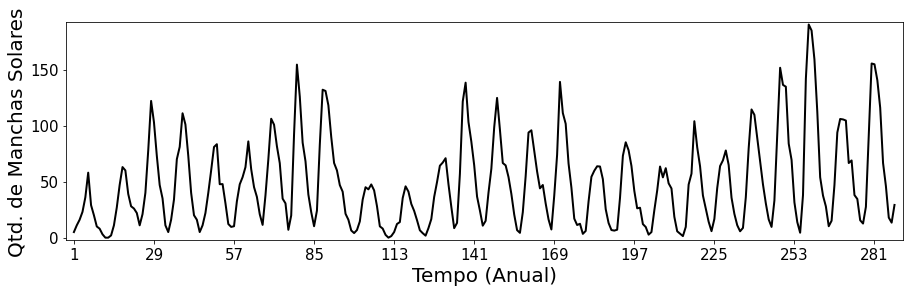

[0, 1, 2, 3, 6, 7, 8, 9, 17, 18]
coloradoRiver
(0.021220965187765808, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


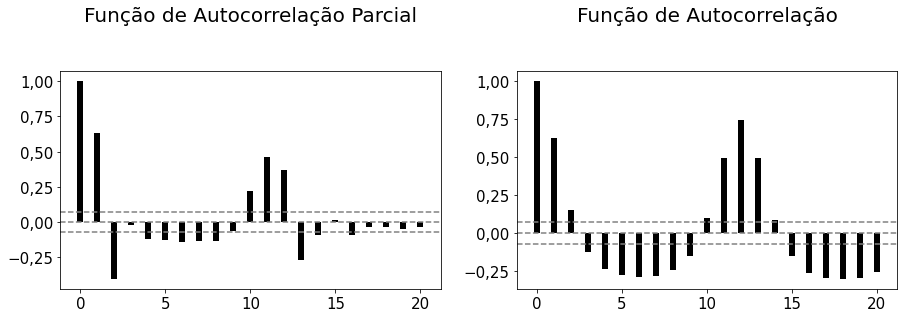

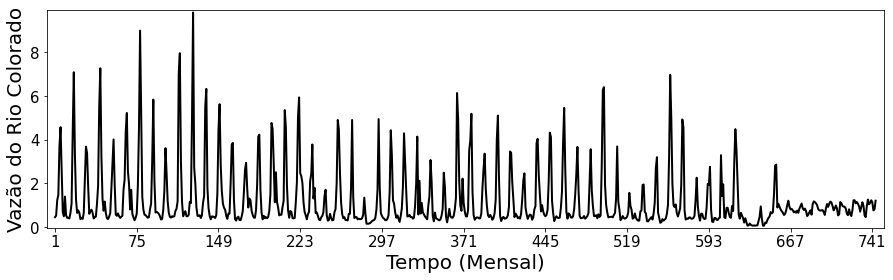

[0, 1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16]
pollution
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


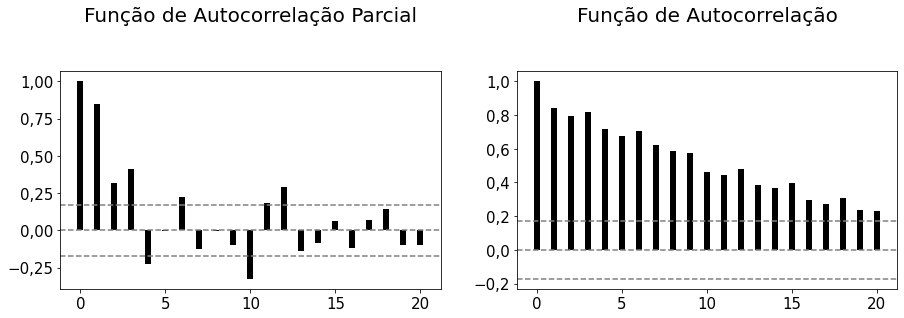

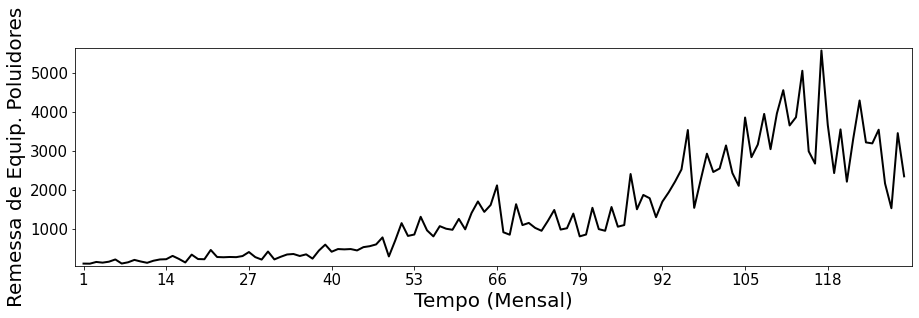

[0, 1, 2, 3, 4, 6, 10, 11, 12]
airlines
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


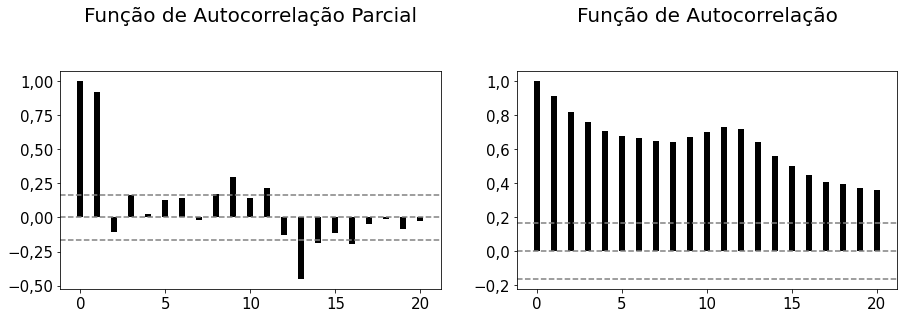

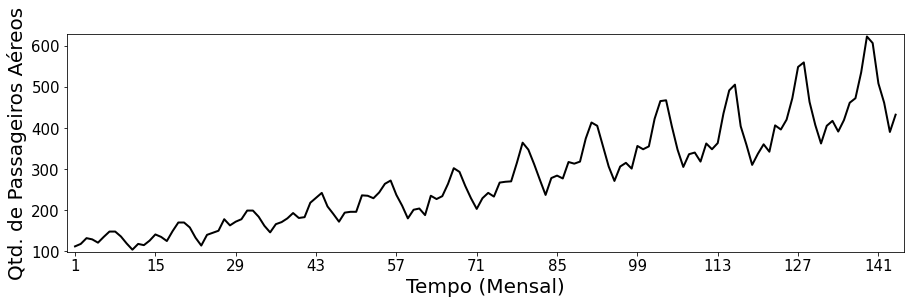

[0, 1, 8, 9, 11, 13, 14, 16]
star
(0.1, False)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


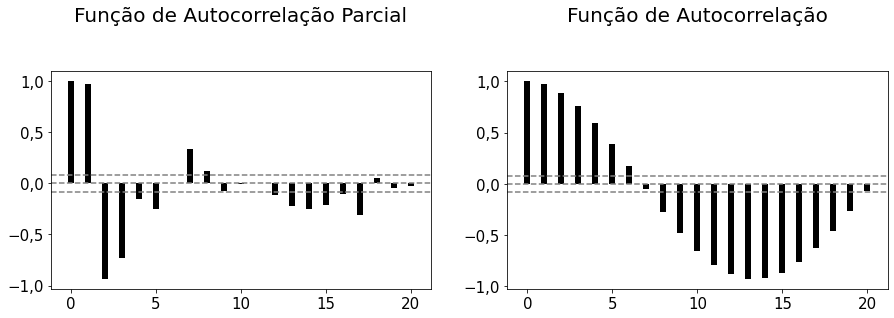

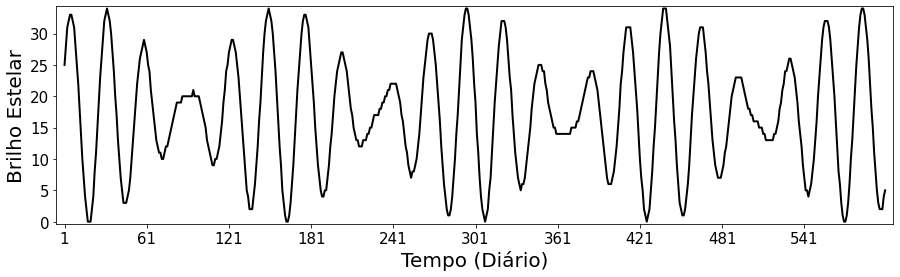

[0, 1, 2, 3, 4, 5, 7, 8, 12, 13, 14, 15, 16, 17]
lakeerie
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


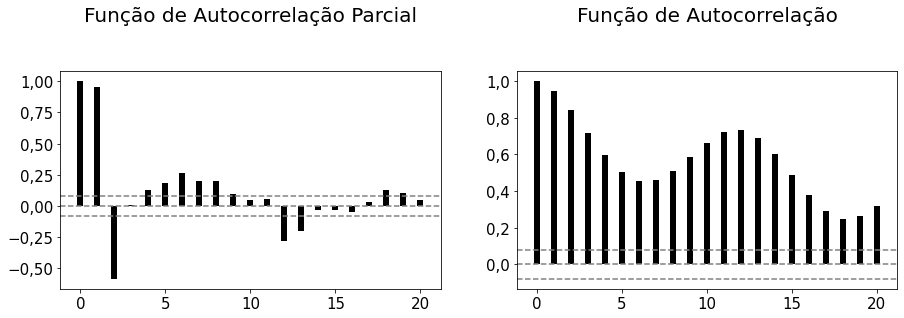

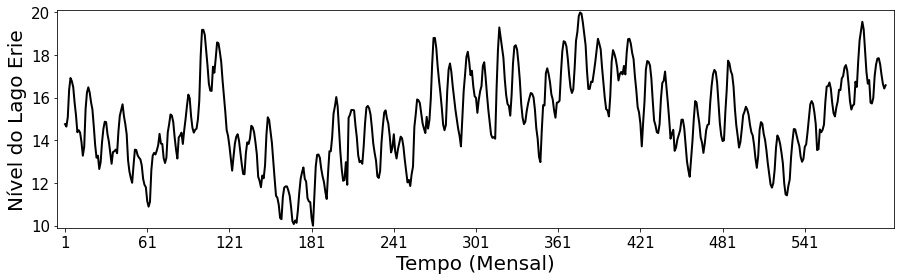

[0, 1, 2, 4, 5, 6, 7, 8, 9, 12, 13, 18, 19]
temperature
(0.1, False)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


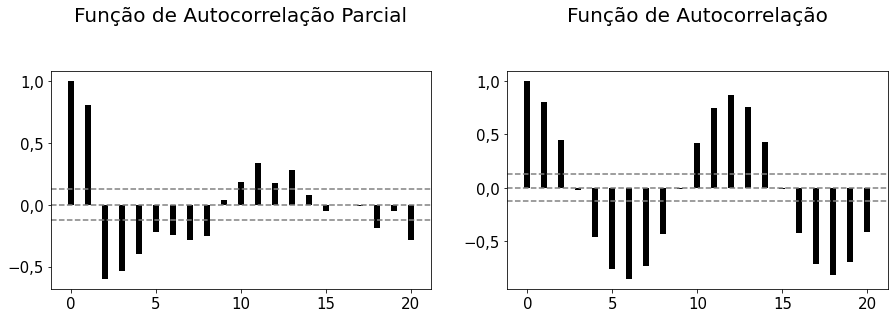

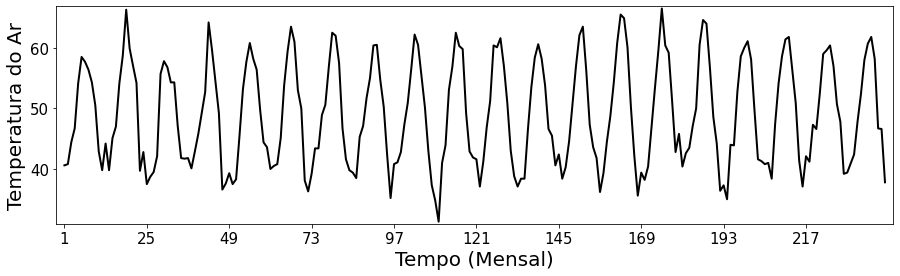

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 18, 20]
paper
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


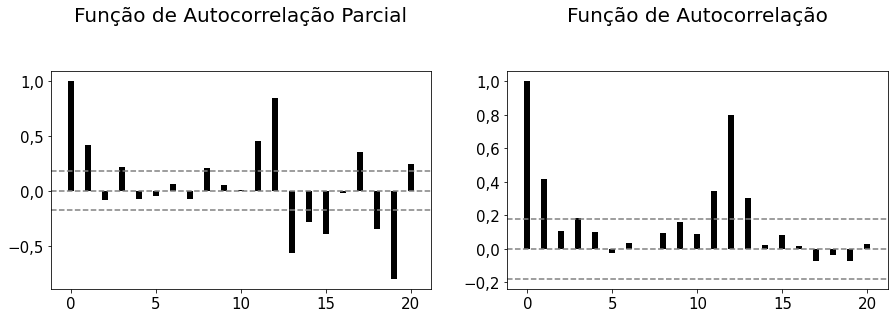

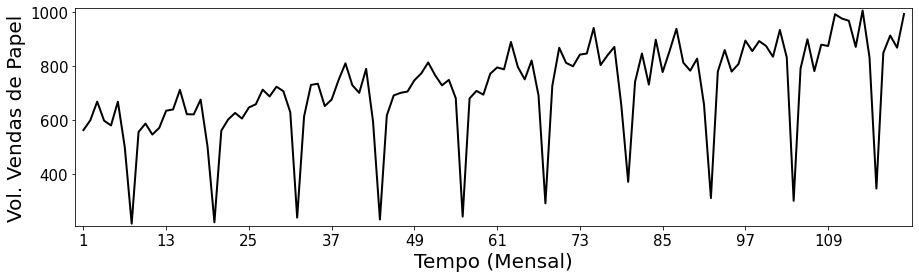

[0, 1, 3, 8, 11, 12, 13, 14, 15, 17, 18, 19, 20]
ibm
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


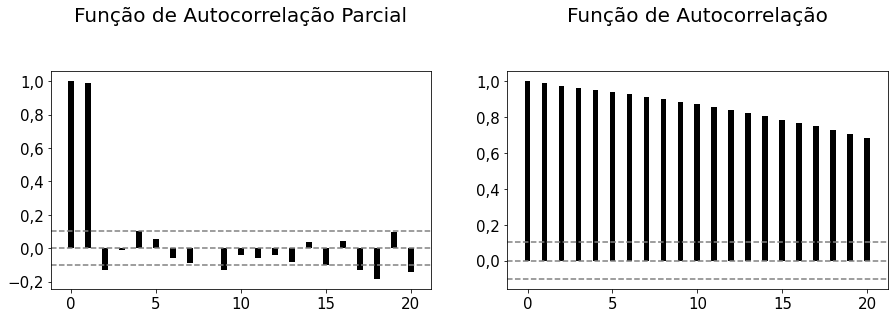

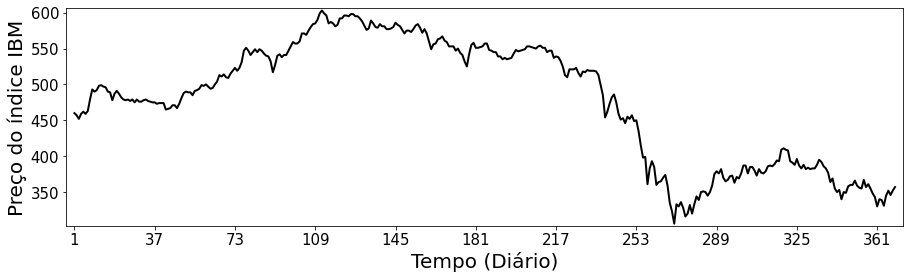

[0, 1, 2, 4, 9, 17, 18, 20]
ozon
(0.1, False)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


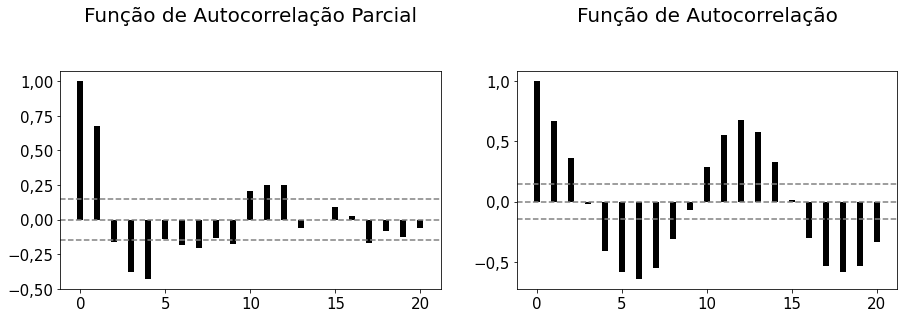

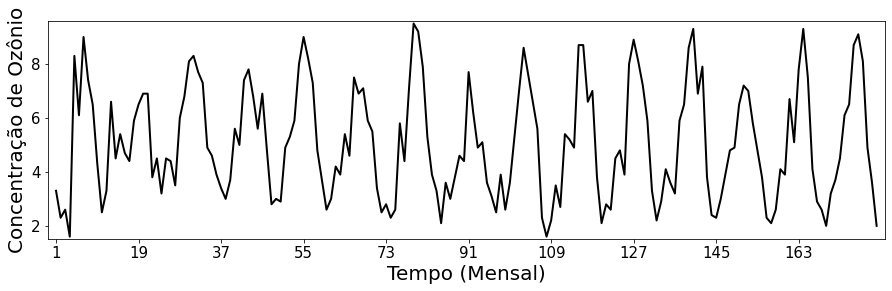

[0, 1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 17]
milk
(0.01, True)


/home/domingos/.local/share/virtualenvs/py_scripts-0ibz-g0E/lib/python3.6/site-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


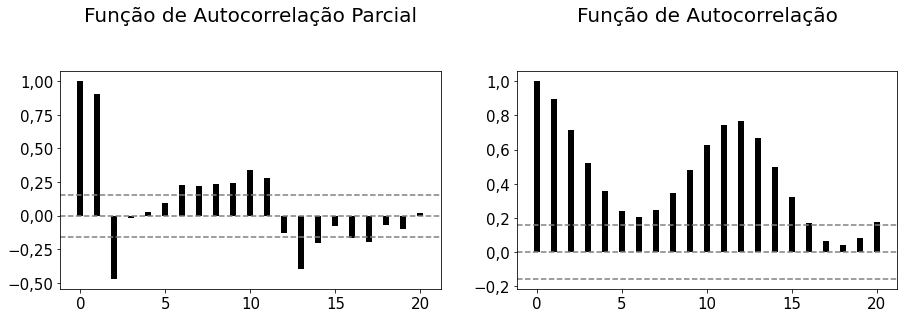

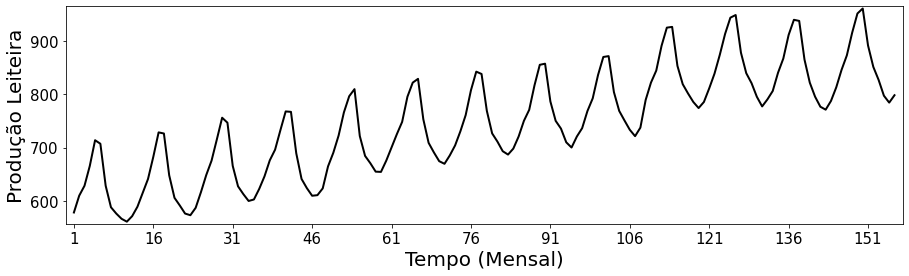

[0, 1, 2, 6, 7, 8, 9, 10, 11, 13, 14, 16, 17]


In [49]:
for i in data[0:-4]:
    
    print(i['name'])
    test_size = i['test_size']
    real = pd.read_csv(i['path_data'],sep=',', names=['actual'])['actual'].values
    kps = KPSSTest()
    print(kps.should_diff(real[0:-test_size]))
    get_acf(real, test_size, i )
    

In [41]:
from pmdarima.arima import CHTest

In [42]:
c = CHTest(12)

In [43]:
c.estimate_seasonal_differencing_term(real)

0

In [44]:
import numpy as np
execs = [932.8422901630402, 904.6814420223236,876.3404278755188,
 943.942351102829,823.1169726848602,939.5518231391907, 846.0990197658539,
 832.5247490406036, 813.962523698806,806.9545617103577]

print(f'{"{:.2f}".format(np.mean(execs))} ({"{:.2f}".format(np.std(execs))})')

872.00 (51.72)


In [45]:
execs = [73.44730257987976,
59.83660697937012,
46.692628622055054,
57.23318362236023,
52.16429686546326,
74.31474304199219,
50.19658184051514,
47.689390420913696,
43.29780101776123,
72.19338607788086,
]

print(f'{"{:.2f}".format(np.mean(execs))} ({"{:.2f}".format(np.std(execs))})')

57.71 (11.20)
